In [90]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv"

In [5]:
df = pd.read_csv(url)

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_81833/4176769558.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [46]:
print(df.head())

   Unique Key   Created Date      Closed Date Agency  Complaint Type  \
0    42680103  5/1/2019 0:00  5/16/2019 21:45    DEP    Water System   
1    42530481  5/1/2019 0:00    5/2/2019 0:00  DOHMH  Food Poisoning   
2    42527619  5/1/2019 0:00   5/13/2019 0:00  DOHMH  Food Poisoning   
3    42526597  5/1/2019 0:00    5/2/2019 0:00  DOHMH  Food Poisoning   
4    42526595  5/1/2019 0:00    5/2/2019 0:00  DOHMH  Food Poisoning   

                Location Type Incident Zip             Incident Address  \
0                         NaN      11420.0            127-16 111 AVENUE   
1  Restaurant/Bar/Deli/Bakery      10011.0         207 WEST   14 STREET   
2  Restaurant/Bar/Deli/Bakery      10025.0                2664 BROADWAY   
3  Restaurant/Bar/Deli/Bakery      11208.0  624 SOUTH CONDUIT BOULEVARD   
4  Restaurant/Bar/Deli/Bakery      11106.0              31-91 21 STREET   

               Street Name Address Type  ... Landmark Facility Type  Status  \
0               111 AVENUE      ADDRE

In [10]:
df.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type',
       'Location Type', 'Incident Zip', 'Incident Address', 'Street Name',
       'Address Type', 'City', 'Landmark', 'Facility Type', 'Status',
       'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude',
       'Longitude', 'Location'],
      dtype='object')

In [16]:
df.dtypes

Unique Key                  int64
Created Date               object
Closed Date                object
Agency                     object
Complaint Type             object
Location Type              object
Incident Zip               object
Incident Address           object
Street Name                object
Address Type               object
City                       object
Landmark                   object
Facility Type              object
Status                     object
Due Date                   object
Resolution Description     object
BBL                       float64
Borough                    object
Latitude                  float64
Longitude                 float64
Location                   object
dtype: object

In [7]:
df.describe()

,Unique Key,BBL,Latitude,Longitude
count,6.963700e+04,5.570200e+04,65634.000000,65634.000000
mean,4.260307e+07,2.869652e+09,40.723149,-73.924517
std,5.269818e+04,1.184250e+09,0.083621,0.085089
min,4.251278e+07,0.000000e+00,40.500025,-74.252279
25%,4.258004e+07,2.030690e+09,40.664461,-73.972161
50%,4.260019e+07,3.034830e+09,40.716443,-73.929758
75%,4.262095e+07,4.023330e+09,40.780783,-73.874064
max,4.297343e+07,5.080480e+09,40.912869,-73.700597


In [28]:
df.groupby(['Borough'])['Unique Key'].count().sort_values(ascending=False)

Borough
BROOKLYN         22247
QUEENS           18623
MANHATTAN        13133
BRONX            10925
STATEN ISLAND     3848
Unspecified        861
Name: Unique Key, dtype: int64

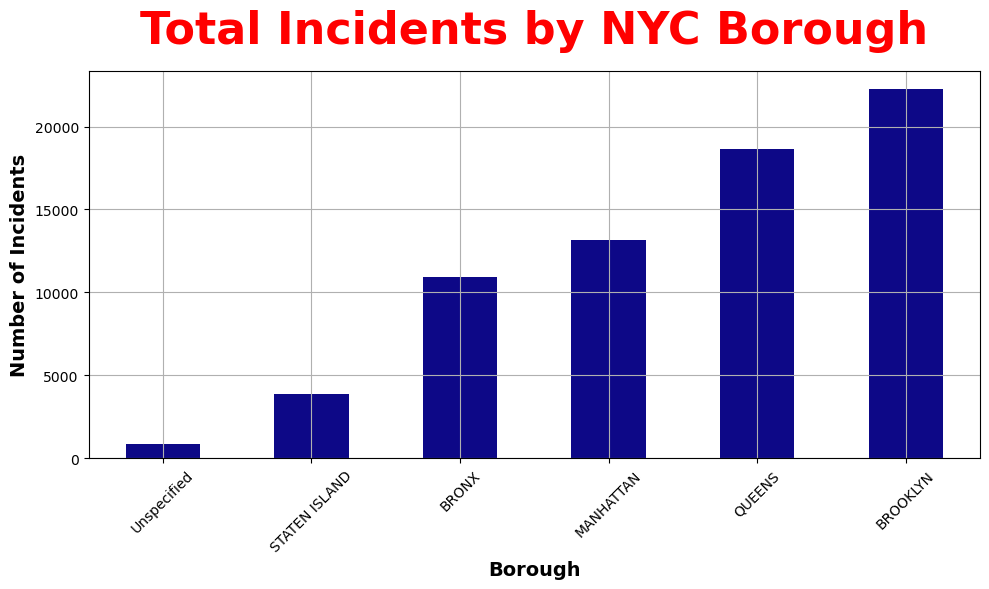

In [84]:
Borough_Counts = df.groupby(['Borough'])['Unique Key'].count().sort_values(ascending=True)

Borough_Counts.plot(
    kind='bar',
    x='Borough',
    y='No of incident',
    grid=True, 
    cmap='plasma',
   title='Total Incidents by NYC Borough',
    legend=False,
    figsize=(10, 6)
)
plt.title(
    "Total Incidents by NYC Borough",
    fontsize=32,
    fontweight="bold",
    color="red",
    pad=20
)
plt.xlabel('Borough', fontsize=14, fontweight="bold" )
plt.ylabel('Number of Incidents', fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

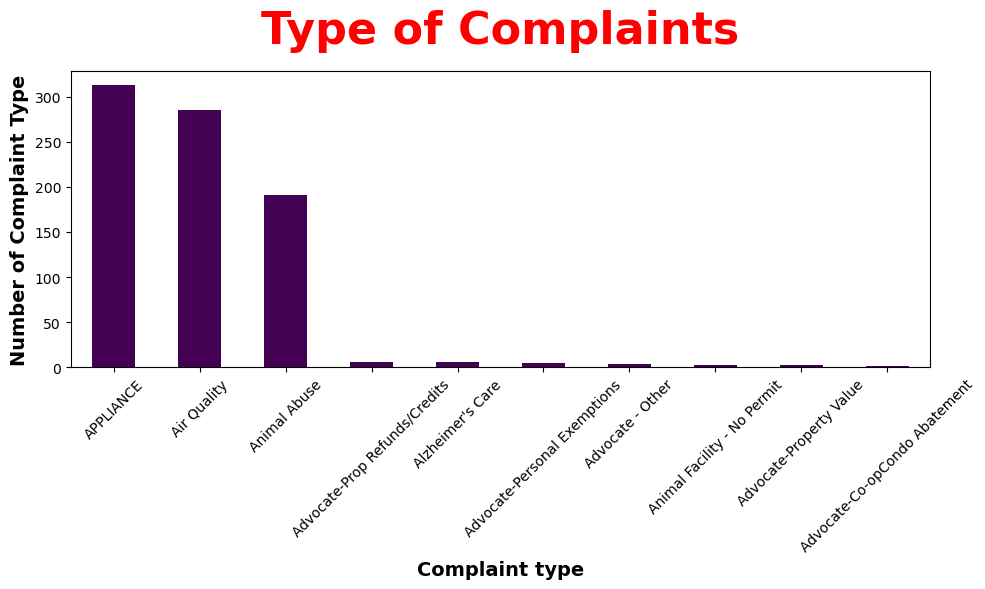

In [86]:
Complaint_Type_Count = df.groupby(['Complaint Type'])['Unique Key'].count().head(10).sort_values(ascending=False)

Complaint_Type_Count.plot(
    kind='bar',
    x='Complaint Type',
    y='No of Complaint Type',
    cmap='viridis',                 # Colormap ('viridis', 'plasma', 'magma', 'coolwarm')
    legend= False,
    figsize= (10, 6)
)
plt.title(
    "Type of Complaints",
    fontsize=32,
    fontweight="bold",
    color="red",
    pad=20
)
plt.xlabel('Complaint type', fontsize=14, fontweight="bold" )
plt.ylabel('Number of Complaint Type', fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

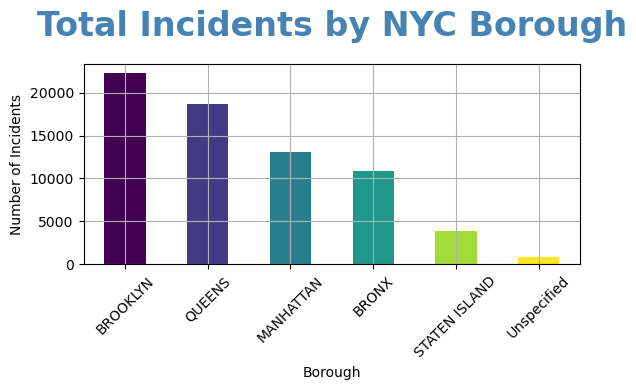

In [53]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Sort the Series from highest to lowest
borough_sorted = Borough_Counts.sort_values(ascending=False)

# Assign a color based on each count
norm = Normalize(
    vmin=borough_sorted.min(),
    vmax=borough_sorted.max()
)

# Low values are light; high values are dark
colors = plt.cm.viridis_r(norm(borough_sorted.values))

borough_sorted.plot(
    kind='bar',
    color=colors,
    grid=True,
    figsize=(6, 4),
    title='Total Incidents by NYC Borough'
)
plt.title(
    "Total Incidents by NYC Borough",
    fontsize=24,
    fontweight="bold",
    color="steelblue",
    pad=20
)

plt.xlabel('Borough')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'Unique Key'}>,
        <Axes: title={'center': 'BBL'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>]], dtype=object)

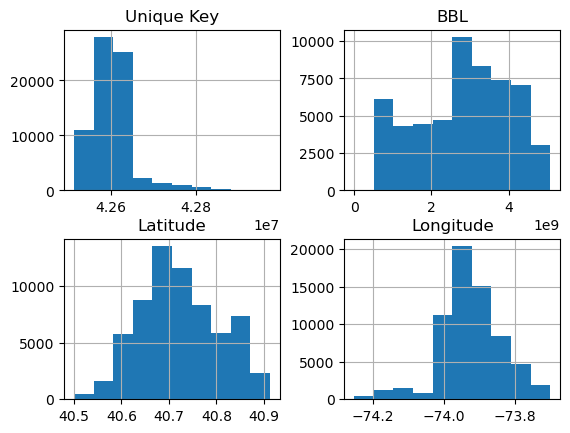

In [13]:
df.hist()

/opt/anaconda3/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1345: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(


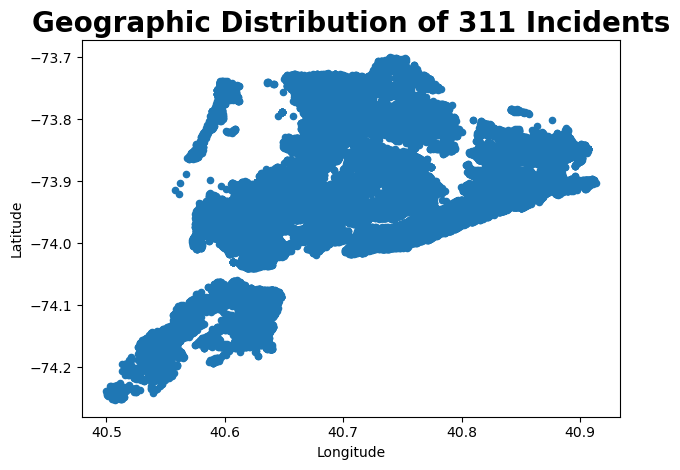

In [68]:
df.plot(kind='scatter', x='Latitude', y='Longitude',
        cmap='rainbow'
)
plt.title("Geographic Distribution of 311 Incidents",
          fontsize=20, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_81833/4144273520.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


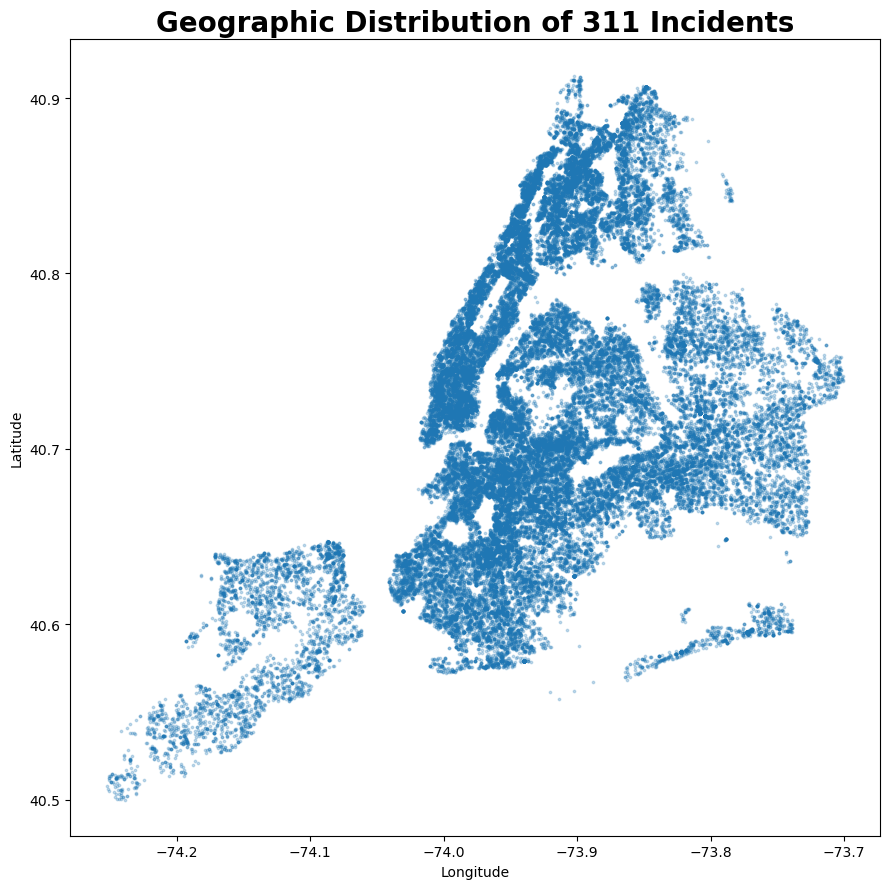

In [61]:
valid_locations = df.dropna(subset=["Latitude", "Longitude"])

plt.figure(figsize=(9, 9))

plt.scatter(
    valid_locations["Longitude"],
    valid_locations["Latitude"],
    s=3,
    alpha=0.25,
    cmap='red',                 
)

plt.title("Geographic Distribution of 311 Incidents",
          fontsize=20, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

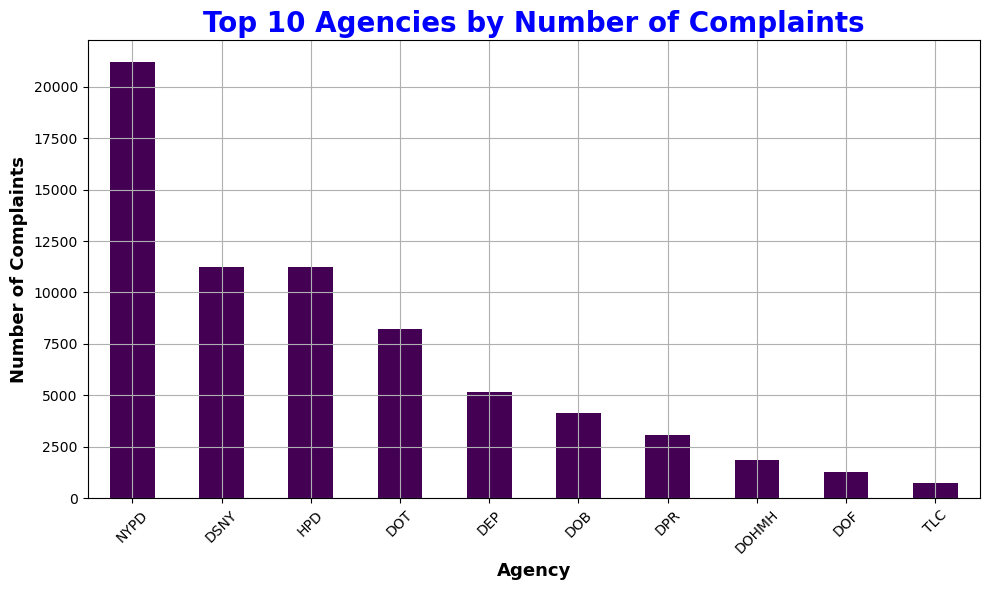

In [82]:
agency_counts = df["Agency"].value_counts().head(10)

agency_counts.plot(
    kind="bar",
    figsize=(10, 6),
    cmap='viridis',                 # Colormap ('viridis', 'plasma', 'magma', 'coolwarm')
      grid=True                       # Add background grid lines
)

plt.title("Top 10 Agencies by Number of Complaints", color='blue', fontsize=20, fontweight="bold")
plt.xlabel("Agency", fontsize=13, fontweight="bold")
plt.ylabel("Number of Complaints", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

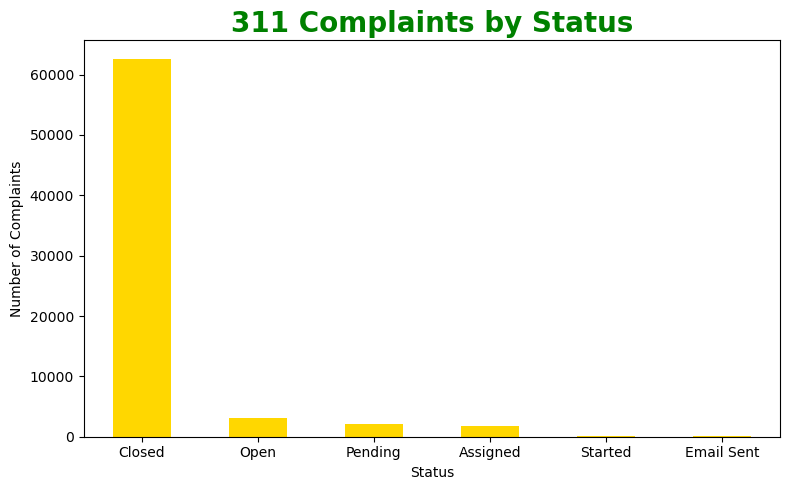

In [80]:
status_counts = df["Status"].value_counts()

status_counts.plot(
    kind="bar",
    figsize=(8, 5),
    color="gold"
)

plt.title("311 Complaints by Status", color="Green", fontsize=20, fontweight="bold")
plt.xlabel("Status")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

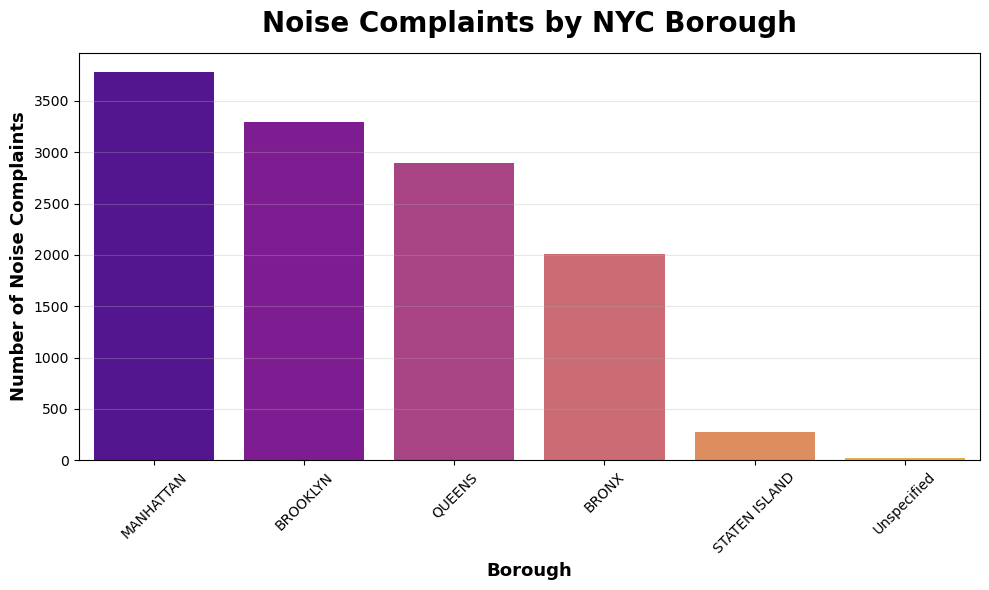

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select complaints containing the word "Noise"
noise_data = df[
    df["Complaint Type"].str.contains(
        "Noise",
        case=False,
        na=False
    )
]

# Count noise complaints by borough
noise_borough_counts = (
    noise_data["Borough"]
    .value_counts()
    .reset_index()
)

noise_borough_counts.columns = [
    "Borough",
    "Number of Noise Complaints"
]

# Create the chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=noise_borough_counts,
    x="Borough",
    y="Number of Noise Complaints",
    hue="Borough",
    palette="plasma",
    legend=False
)

plt.title(
    "Noise Complaints by NYC Borough",
    fontsize=20,
    fontweight="bold",
    pad=15
)

plt.xlabel("Borough", fontsize=13, fontweight="bold")
plt.ylabel("Number of Noise Complaints", fontsize=13, fontweight="bold")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()